In [1]:
import pandas as pd

In [2]:
# Importing the dataset
df=pd.read_csv('/Users/spriha/Desktop/ML Projects/UBER RIDE STATUS/ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


EDA AND FEATURE ENGINEERING

In [3]:
# Displaying the first few rows of the dataset
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [4]:
# Checking for null values
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [5]:
# dropping duplicates based on 'Booking ID'
df.drop_duplicates(subset='Booking ID', keep='first', inplace=True)

In [6]:
# Verifying
df['Booking ID'].duplicated().sum()

np.int64(0)

In [7]:
# Checking for null values in 'Ride Distance'
df['Ride Distance'].isnull().sum()

np.int64(47592)

In [8]:
# Finding rows where 'Ride Distance' is null and reason
null_ride_distance_row = df[df['Ride Distance'].isnull()]
print(null_ride_distance_row)

              Date      Time    Booking ID       Booking Status   Customer ID  \
0       2024-03-23  12:29:38  "CNR5884300"      No Driver Found  "CID1982111"   
8       2024-09-14  12:49:09  "CNR4510807"      No Driver Found  "CID7873618"   
11      2024-09-18  08:09:38  "CNR9551927"      No Driver Found  "CID7568143"   
12      2024-06-25  22:44:15  "CNR4386945"  Cancelled by Driver  "CID5543520"   
17      2024-12-15  15:08:25  "CNR6739317"  Cancelled by Driver  "CID8682675"   
...            ...       ...           ...                  ...           ...   
149979  2024-10-05  17:30:25  "CNR8459494"  Cancelled by Driver  "CID9568404"   
149980  2024-12-10  15:31:45  "CNR6231822"      No Driver Found  "CID6232718"   
149982  2024-11-13  06:51:19  "CNR4448255"      No Driver Found  "CID9138957"   
149990  2024-09-26  12:31:22  "CNR3212810"  Cancelled by Driver  "CID6199171"   
149992  2024-01-24  18:02:28  "CNR1717894"      No Driver Found  "CID9564749"   

         Vehicle Type     P

In [9]:
# Filling null values with specific values
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(0)
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].fillna(0)
df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].fillna('Not Applicable')
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].fillna('Not Applicable')


In [10]:
# Checking the columns of the DataFrame
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [11]:
# Creating a new column 'Ride Status' for a target column

def classify_ride(row):
    if row['Cancelled Rides by Customer'] == 1.0:
        return 'Cancelled by Customer'
    if row['Cancelled Rides by Driver'] == 1.0:
        return 'Cancelled by Driver'
    if row['Incomplete Rides'] == 1.0:
        return 'Incomplete Ride'
    else:
        return 'Completed Ride'

df['Ride Status'] = df.apply(classify_ride, axis=1)
df.loc[df["Booking Status"] == "No Driver Found", "Ride Status"] = "Driver Not Found"
df.drop(['Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides', 'Booking Status'], axis=1, inplace=True)
df

,Date,Time,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Ride Status
0,2024-03-23,12:29:38,"""CNR5884300""","""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,Not Applicable,Not Applicable,NaN,NaN,NaN,NaN,NaN,NaN,Driver Not Found
1,2024-11-29,18:01:39,"""CNR1326809""","""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,Not Applicable,Not Applicable,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,Incomplete Ride
2,2024-08-23,08:56:10,"""CNR8494506""","""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,Not Applicable,Not Applicable,NaN,627.0,13.58,4.9,4.9,Debit Card,Completed Ride
3,2024-10-21,17:17:25,"""CNR8906825""","""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,Not Applicable,Not Applicable,NaN,416.0,34.02,4.6,5.0,UPI,Completed Ride
4,2024-09-16,22:08:00,"""CNR1950162""","""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,Not Applicable,Not Applicable,NaN,737.0,48.21,4.1,4.3,UPI,Completed Ride
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""","""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,Not Applicable,Not Applicable,NaN,475.0,40.08,3.7,4.1,Uber Wallet,Completed Ride
149996,2024-11-24,15:55:09,"""CNR2468611""","""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,Not Applicable,Not Applicable,NaN,1093.0,21.31,4.8,5.0,UPI,Completed Ride
149997,2024-09-18,10:55:15,"""CNR6358306""","""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,Not Applicable,Not Applicable,NaN,852.0,15.93,3.9,4.4,Cash,Completed Ride
149998,2024-10-05,07:53:34,"""CNR3030099""","""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,Not Applicable,Not Applicable,NaN,333.0,45.54,4.1,3.7,UPI,Completed Ride


In [12]:
# Displaying the value counts of the 'Ride Status' column
df['Ride Status'].value_counts()

Ride Status
Completed Ride           92248
Cancelled by Driver      26789
Cancelled by Customer    10402
Driver Not Found         10401
Incomplete Ride           8927
Name: count, dtype: int64

In [13]:
# 1. Add a flag column for Driver Not Found cases
df["Is_NoDriverFound"] = (df["Ride Status"] == "Driver Not Found").astype(int)

# 2. Set ride-dependent features to 0 for Driver Not Found cases
cols_to_zero = ["Avg VTAT", "Avg CTAT", "Ride Distance"]

df.loc[df["Ride Status"] == "Driver Not Found", cols_to_zero] = 0
df

,Date,Time,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Ride Status,Is_NoDriverFound
0,2024-03-23,12:29:38,"""CNR5884300""","""CID1982111""",eBike,Palam Vihar,Jhilmil,0.0,0.0,Not Applicable,Not Applicable,NaN,NaN,0.00,NaN,NaN,NaN,Driver Not Found,1
1,2024-11-29,18:01:39,"""CNR1326809""","""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,Not Applicable,Not Applicable,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,Incomplete Ride,0
2,2024-08-23,08:56:10,"""CNR8494506""","""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,Not Applicable,Not Applicable,NaN,627.0,13.58,4.9,4.9,Debit Card,Completed Ride,0
3,2024-10-21,17:17:25,"""CNR8906825""","""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,Not Applicable,Not Applicable,NaN,416.0,34.02,4.6,5.0,UPI,Completed Ride,0
4,2024-09-16,22:08:00,"""CNR1950162""","""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,Not Applicable,Not Applicable,NaN,737.0,48.21,4.1,4.3,UPI,Completed Ride,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""","""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,Not Applicable,Not Applicable,NaN,475.0,40.08,3.7,4.1,Uber Wallet,Completed Ride,0
149996,2024-11-24,15:55:09,"""CNR2468611""","""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,Not Applicable,Not Applicable,NaN,1093.0,21.31,4.8,5.0,UPI,Completed Ride,0
149997,2024-09-18,10:55:15,"""CNR6358306""","""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,Not Applicable,Not Applicable,NaN,852.0,15.93,3.9,4.4,Cash,Completed Ride,0
149998,2024-10-05,07:53:34,"""CNR3030099""","""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,Not Applicable,Not Applicable,NaN,333.0,45.54,4.1,3.7,UPI,Completed Ride,0


In [14]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Customer ID', 'Vehicle Type',
       'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT',
       'Reason for cancelling by Customer', 'Driver Cancellation Reason',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'Ride Status',
       'Is_NoDriverFound'],
      dtype='object')

In [15]:
# Dropping unnecessary columns
drop_cols = [
    "Booking ID", "Customer ID",
    "Reason for cancelling by Customer",
    "Driver Cancellation Reason",
    "Incomplete Rides Reason"
]
df = df.drop(columns=drop_cols)
df

,Date,Time,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Ride Status,Is_NoDriverFound
0,2024-03-23,12:29:38,eBike,Palam Vihar,Jhilmil,0.0,0.0,NaN,0.00,NaN,NaN,NaN,Driver Not Found,1
1,2024-11-29,18:01:39,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,NaN,NaN,UPI,Incomplete Ride,0
2,2024-08-23,08:56:10,Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,Completed Ride,0
3,2024-10-21,17:17:25,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI,Completed Ride,0
4,2024-09-16,22:08:00,Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,Completed Ride,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,Go Mini,MG Road,Ghitorni,10.2,44.4,475.0,40.08,3.7,4.1,Uber Wallet,Completed Ride,0
149996,2024-11-24,15:55:09,Go Mini,Golf Course Road,Akshardham,5.1,30.8,1093.0,21.31,4.8,5.0,UPI,Completed Ride,0
149997,2024-09-18,10:55:15,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,852.0,15.93,3.9,4.4,Cash,Completed Ride,0
149998,2024-10-05,07:53:34,Auto,Ghaziabad,Saidulajab,6.9,39.6,333.0,45.54,4.1,3.7,UPI,Completed Ride,0


In [16]:
# Converting 'Date' and 'Time' columns to datetime and extracting features
df["Date"] = pd.to_datetime(df["Date"])
df["DayOfWeek"] = df["Date"].dt.dayofweek       # Monday=0, Sunday=6
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour

df

,Date,Time,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Ride Status,Is_NoDriverFound,DayOfWeek,IsWeekend,Hour
0,2024-03-23,12:29:38,eBike,Palam Vihar,Jhilmil,0.0,0.0,NaN,0.00,NaN,NaN,NaN,Driver Not Found,1,5,1,12
1,2024-11-29,18:01:39,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,NaN,NaN,UPI,Incomplete Ride,0,4,0,18
2,2024-08-23,08:56:10,Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,Completed Ride,0,4,0,8
3,2024-10-21,17:17:25,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI,Completed Ride,0,0,0,17
4,2024-09-16,22:08:00,Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,Completed Ride,0,0,0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,Go Mini,MG Road,Ghitorni,10.2,44.4,475.0,40.08,3.7,4.1,Uber Wallet,Completed Ride,0,0,0,19
149996,2024-11-24,15:55:09,Go Mini,Golf Course Road,Akshardham,5.1,30.8,1093.0,21.31,4.8,5.0,UPI,Completed Ride,0,6,1,15
149997,2024-09-18,10:55:15,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,852.0,15.93,3.9,4.4,Cash,Completed Ride,0,2,0,10
149998,2024-10-05,07:53:34,Auto,Ghaziabad,Saidulajab,6.9,39.6,333.0,45.54,4.1,3.7,UPI,Completed Ride,0,5,1,7


In [17]:
# Dropping the original 'Date' and 'Time' columns
drop_cols = ['Date', 'Time']
df = df.drop(columns=drop_cols)
df

,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Ride Status,Is_NoDriverFound,DayOfWeek,IsWeekend,Hour
0,eBike,Palam Vihar,Jhilmil,0.0,0.0,NaN,0.00,NaN,NaN,NaN,Driver Not Found,1,5,1,12
1,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,NaN,NaN,UPI,Incomplete Ride,0,4,0,18
2,Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,Completed Ride,0,4,0,8
3,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI,Completed Ride,0,0,0,17
4,Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,Completed Ride,0,0,0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,Go Mini,MG Road,Ghitorni,10.2,44.4,475.0,40.08,3.7,4.1,Uber Wallet,Completed Ride,0,0,0,19
149996,Go Mini,Golf Course Road,Akshardham,5.1,30.8,1093.0,21.31,4.8,5.0,UPI,Completed Ride,0,6,1,15
149997,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,852.0,15.93,3.9,4.4,Cash,Completed Ride,0,2,0,10
149998,Auto,Ghaziabad,Saidulajab,6.9,39.6,333.0,45.54,4.1,3.7,UPI,Completed Ride,0,5,1,7


In [18]:
# Adding frequency counts for Pickup and Drop Locations
# Too many different locations, so we will add frequency counts instead of one-hot encoding
for col in ["Pickup Location", "Drop Location"]:
    freq = df[col].value_counts()
    df[col + "_freq"] = df[col].map(freq)

df

,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Ride Status,Is_NoDriverFound,DayOfWeek,IsWeekend,Hour,Pickup Location_freq,Drop Location_freq
0,eBike,Palam Vihar,Jhilmil,0.0,0.0,NaN,0.00,NaN,NaN,NaN,Driver Not Found,1,5,1,12,813,849
1,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,NaN,NaN,UPI,Incomplete Ride,0,4,0,18,860,885
2,Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,Completed Ride,0,4,0,8,947,826
3,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI,Completed Ride,0,0,0,17,833,831
4,Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,Completed Ride,0,0,0,22,780,863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,Go Mini,MG Road,Ghitorni,10.2,44.4,475.0,40.08,3.7,4.1,Uber Wallet,Completed Ride,0,0,0,19,811,866
149996,Go Mini,Golf Course Road,Akshardham,5.1,30.8,1093.0,21.31,4.8,5.0,UPI,Completed Ride,0,6,1,15,811,843
149997,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,852.0,15.93,3.9,4.4,Cash,Completed Ride,0,2,0,10,838,825
149998,Auto,Ghaziabad,Saidulajab,6.9,39.6,333.0,45.54,4.1,3.7,UPI,Completed Ride,0,5,1,7,842,833


In [19]:
df['Pickup Location_freq'].value_counts()

Pickup Location_freq
856    5992
872    4360
860    4300
844    4220
834    4170
       ... 
797     797
795     795
791     791
789     789
780     780
Name: count, Length: 87, dtype: int64

In [20]:
# Dropping the original 'Pickup Location' and 'Drop Location' columns
drop_cols = ['Pickup Location', 'Drop Location']
df = df.drop(columns=drop_cols)
df

,Vehicle Type,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Ride Status,Is_NoDriverFound,DayOfWeek,IsWeekend,Hour,Pickup Location_freq,Drop Location_freq
0,eBike,0.0,0.0,NaN,0.00,NaN,NaN,NaN,Driver Not Found,1,5,1,12,813,849
1,Go Sedan,4.9,14.0,237.0,5.73,NaN,NaN,UPI,Incomplete Ride,0,4,0,18,860,885
2,Auto,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,Completed Ride,0,4,0,8,947,826
3,Premier Sedan,13.1,28.5,416.0,34.02,4.6,5.0,UPI,Completed Ride,0,0,0,17,833,831
4,Bike,5.3,19.6,737.0,48.21,4.1,4.3,UPI,Completed Ride,0,0,0,22,780,863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,Go Mini,10.2,44.4,475.0,40.08,3.7,4.1,Uber Wallet,Completed Ride,0,0,0,19,811,866
149996,Go Mini,5.1,30.8,1093.0,21.31,4.8,5.0,UPI,Completed Ride,0,6,1,15,811,843
149997,Go Sedan,2.7,23.4,852.0,15.93,3.9,4.4,Cash,Completed Ride,0,2,0,10,838,825
149998,Auto,6.9,39.6,333.0,45.54,4.1,3.7,UPI,Completed Ride,0,5,1,7,842,833


In [21]:
# One-hot encoding categorical variables
df = pd.get_dummies(df, columns=["Vehicle Type", "Payment Method"], drop_first=True)
df

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Ride Status,Is_NoDriverFound,DayOfWeek,IsWeekend,...,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet
0,0.0,0.0,NaN,0.00,NaN,NaN,Driver Not Found,1,5,1,...,False,False,False,False,False,True,False,False,False,False
1,4.9,14.0,237.0,5.73,NaN,NaN,Incomplete Ride,0,4,0,...,False,False,True,False,False,False,False,False,True,False
2,13.4,25.8,627.0,13.58,4.9,4.9,Completed Ride,0,4,0,...,False,False,False,False,False,False,False,True,False,False
3,13.1,28.5,416.0,34.02,4.6,5.0,Completed Ride,0,0,0,...,False,False,False,True,False,False,False,False,True,False
4,5.3,19.6,737.0,48.21,4.1,4.3,Completed Ride,0,0,0,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,10.2,44.4,475.0,40.08,3.7,4.1,Completed Ride,0,0,0,...,False,True,False,False,False,False,False,False,False,True
149996,5.1,30.8,1093.0,21.31,4.8,5.0,Completed Ride,0,6,1,...,False,True,False,False,False,False,False,False,True,False
149997,2.7,23.4,852.0,15.93,3.9,4.4,Completed Ride,0,2,0,...,False,False,True,False,False,False,False,False,False,False
149998,6.9,39.6,333.0,45.54,4.1,3.7,Completed Ride,0,5,1,...,False,False,False,False,False,False,False,False,True,False


In [22]:
# Filling remaining null values with 0 for numerical columns
for col in ["Avg VTAT", "Avg CTAT", "Ride Distance", "Booking Value","Driver Ratings", "Customer Rating"]:
    df[col] = df[col].fillna(0)

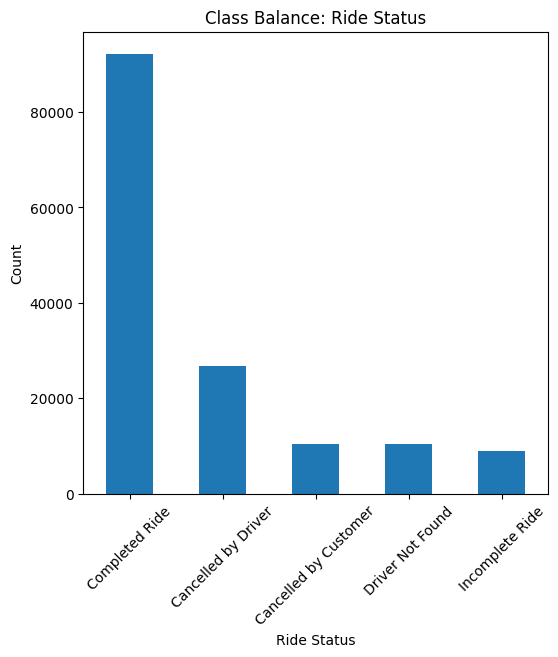

In [23]:
# Checking Class Balance
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
df["Ride Status"].value_counts().plot(kind="bar")
plt.title("Class Balance: Ride Status")
plt.xlabel("Ride Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


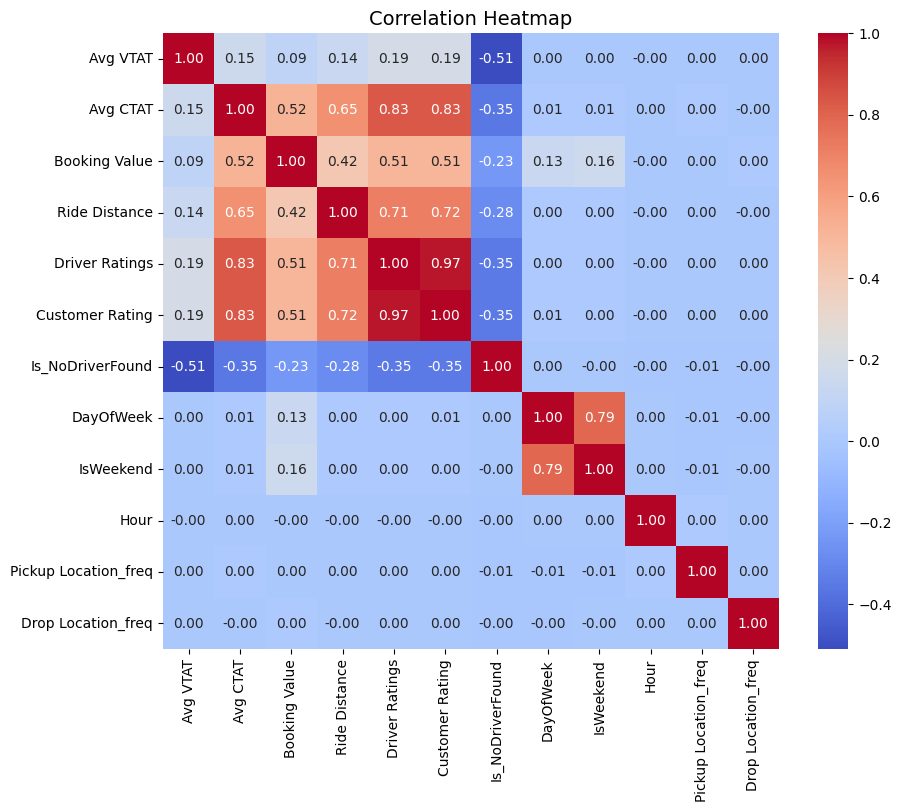

In [24]:
# Heatmap for correlation

import seaborn as sns
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", square=True,
            cbar=True, xticklabels=corr.columns, yticklabels=corr.columns)
plt.title("Correlation Heatmap", fontsize=14)
plt.show()


In [25]:
# Dropping 'Customer Rating' column as it has high correlation with 'Driver Ratings 0.97'
df.drop(columns=["Customer Rating"], inplace=True)
df

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Ride Status,Is_NoDriverFound,DayOfWeek,IsWeekend,Hour,...,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet
0,0.0,0.0,0.0,0.00,0.0,Driver Not Found,1,5,1,12,...,False,False,False,False,False,True,False,False,False,False
1,4.9,14.0,237.0,5.73,0.0,Incomplete Ride,0,4,0,18,...,False,False,True,False,False,False,False,False,True,False
2,13.4,25.8,627.0,13.58,4.9,Completed Ride,0,4,0,8,...,False,False,False,False,False,False,False,True,False,False
3,13.1,28.5,416.0,34.02,4.6,Completed Ride,0,0,0,17,...,False,False,False,True,False,False,False,False,True,False
4,5.3,19.6,737.0,48.21,4.1,Completed Ride,0,0,0,22,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,10.2,44.4,475.0,40.08,3.7,Completed Ride,0,0,0,19,...,False,True,False,False,False,False,False,False,False,True
149996,5.1,30.8,1093.0,21.31,4.8,Completed Ride,0,6,1,15,...,False,True,False,False,False,False,False,False,True,False
149997,2.7,23.4,852.0,15.93,3.9,Completed Ride,0,2,0,10,...,False,False,True,False,False,False,False,False,False,False
149998,6.9,39.6,333.0,45.54,4.1,Completed Ride,0,5,1,7,...,False,False,False,False,False,False,False,False,True,False


In [26]:
# Scaling numerical features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
colscale = ['Avg VTAT', 'Avg CTAT', 'Ride Distance', 'Booking Value']
df[colscale] = scaler.fit_transform(df[colscale])
df

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Ride Status,Is_NoDriverFound,DayOfWeek,IsWeekend,Hour,...,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet
0,-1.859135,-1.282990,-0.856713,-1.028588,0.0,Driver Not Found,1,5,1,12,...,False,False,False,False,False,True,False,False,False,False
1,-0.700678,-0.376960,-0.269352,-0.676888,0.0,Incomplete Ride,0,4,0,18,...,False,False,True,False,False,False,False,False,True,False
2,1.308890,0.386693,0.697192,-0.195066,4.9,Completed Ride,0,4,0,8,...,False,False,False,False,False,False,False,True,False,False
3,1.237964,0.561428,0.174267,1.059513,4.6,Completed Ride,0,0,0,17,...,False,False,False,True,False,False,False,False,True,False
4,-0.606110,-0.014548,0.969807,1.930476,4.1,Completed Ride,0,0,0,22,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0.552347,1.590419,0.320488,1.431467,3.7,Completed Ride,0,0,0,19,...,False,True,False,False,False,False,False,False,False,True
149996,-0.653394,0.710276,1.852089,0.279391,4.8,Completed Ride,0,6,1,15,...,False,True,False,False,False,False,False,False,True,False
149997,-1.220801,0.231374,1.254814,-0.050826,3.9,Completed Ride,0,2,0,10,...,False,False,True,False,False,False,False,False,False,False
149998,-0.227838,1.279780,-0.031433,1.766595,4.1,Completed Ride,0,5,1,7,...,False,False,False,False,False,False,False,False,True,False


In [27]:
# Splitting the dataset into features and target variable
X = df.drop(columns=["Ride Status"])
y = df["Ride Status"]

In [28]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


LOGISTIC REGRESSION

In [29]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix 

log_reg = LogisticRegression(solver='saga', max_iter=5000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

print("Logistic Regression Performance")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Performance
[[ 1371  1230     0     0     0]
 [   49  6648     0     0     0]
 [    0     0 23061     0     1]
 [    0     0     0  2600     0]
 [    0     5     0     0  2227]]
                       precision    recall  f1-score   support

Cancelled by Customer       0.97      0.53      0.68      2601
  Cancelled by Driver       0.84      0.99      0.91      6697
       Completed Ride       1.00      1.00      1.00     23062
     Driver Not Found       1.00      1.00      1.00      2600
      Incomplete Ride       1.00      1.00      1.00      2232

             accuracy                           0.97     37192
            macro avg       0.96      0.90      0.92     37192
         weighted avg       0.97      0.97      0.96     37192



RANDOM FOREST

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Performance")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
[[ 1379  1222     0     0     0]
 [   33  6664     0     0     0]
 [    0     0 23062     0     0]
 [    0     0     0  2600     0]
 [    0     0     0     0  2232]]
                       precision    recall  f1-score   support

Cancelled by Customer       0.98      0.53      0.69      2601
  Cancelled by Driver       0.85      1.00      0.91      6697
       Completed Ride       1.00      1.00      1.00     23062
     Driver Not Found       1.00      1.00      1.00      2600
      Incomplete Ride       1.00      1.00      1.00      2232

             accuracy                           0.97     37192
            macro avg       0.96      0.91      0.92     37192
         weighted avg       0.97      0.97      0.96     37192



 LIGHTGBM

In [31]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    class_weight="balanced",
    random_state=42
)


lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM Performance")   
print(confusion_matrix(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1193
[LightGBM] [Info] Number of data points in the train set: 111575, number of used features: 21
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Performance
[[ 1422  1179     0     0     0]
 [  187  6510    

LIGHTGBM WITH SMOTE

In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy={'Cancelled by Customer': int(y_train.value_counts().max())}, 
    random_state=42
)
X_res, y_res = smote.fit_resample(X_train, y_train)
 
lgbm = LGBMClassifier(
    random_state=42
)

lgbm.fit(X_res, y_res)

y_pred_lgbm_res = lgbm.predict(X_test)

print("LightGBM with SMOTE Performance")
print(confusion_matrix(y_test, y_pred_lgbm_res))
print(classification_report(y_test, y_pred_lgbm_res))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1385
[LightGBM] [Info] Number of data points in the train set: 172960, number of used features: 21
[LightGBM] [Info] Start training from score -0.916262
[LightGBM] [Info] Start training from score -2.152739
[LightGBM] [Info] Start training from score -0.916262
[LightGBM] [Info] Start training from score -3.098808
[LightGBM] [Info] Start training from score -3.251699
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM with SMOTE Performance
[[ 1403  1198     0     0     0]
 [  12

XGBOOST

In [33]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import numpy as np

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# --- Fix SMOTE: oversample rare classes only ---
class_counts = np.bincount(y_train)
max_class = max(class_counts)

# Build strategy dict: upsample only classes below 80% of max
smote_strategy = {cls: int(0.8 * max_class) for cls, count in enumerate(class_counts) if count < 0.8 * max_class}

print("SMOTE strategy:", smote_strategy)

smote = SMOTE(sampling_strategy=smote_strategy, random_state=42, k_neighbors=5)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("Before oversampling:", dict(zip(np.unique(y_train), np.bincount(y_train))))
print("After oversampling:", dict(zip(np.unique(y_res), np.bincount(y_res))))

# Define XGBoost model
xgb_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(y.unique()),
    eval_metric="mlogloss",
    random_state=42,
    n_estimators=400,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=None  # not needed with SMOTE
)

# Train
xgb_model.fit(X_res, y_res)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))


SMOTE strategy: {0: 55348, 1: 55348, 3: 55348, 4: 55348}
Before oversampling: {np.int64(0): np.int64(7801), np.int64(1): np.int64(20092), np.int64(2): np.int64(69186), np.int64(3): np.int64(7801), np.int64(4): np.int64(6695)}
After oversampling: {np.int64(0): np.int64(55348), np.int64(1): np.int64(55348), np.int64(2): np.int64(69186), np.int64(3): np.int64(55348), np.int64(4): np.int64(55348)}

Confusion Matrix:
 [[ 1462  1139     0     0     0]
 [  409  6288     0     0     0]
 [    0     0 23062     0     0]
 [    0     0     0  2600     0]
 [    0     1     0     0  2231]]

Classification Report:
                        precision    recall  f1-score   support

Cancelled by Customer       0.78      0.56      0.65      2601
  Cancelled by Driver       0.85      0.94      0.89      6697
       Completed Ride       1.00      1.00      1.00     23062
     Driver Not Found       1.00      1.00      1.00      2600
      Incomplete Ride       1.00      1.00      1.00      2232

            

XGBOOST WITH INVERSE CLASS WEIGHTING

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# -------------------------------
# 1. Split data
# -------------------------------
X = df.drop("Ride Status", axis=1)
y = df["Ride Status"]

# Encode target if needed
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------------
# 2. Compute class weights
# -------------------------------
classes = np.unique(y_train)
class_counts = np.bincount(y_train)

# Inverse frequency weighting
class_weights = {cls: len(y_train) / (len(classes) * count)
                 for cls, count in zip(classes, class_counts)}

print("Class weights:", class_weights)

# -------------------------------
# 3. Train XGBoost with weights
# -------------------------------
sample_weights = np.array([class_weights[cls] for cls in y_train])

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=len(classes),
    eval_metric="auc",
    random_state=42,
    n_estimators=300,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(X_train, y_train, sample_weight=sample_weights)

# -------------------------------
# 4. Evaluate
# -------------------------------
y_pred = xgb.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Class weights: {np.int64(0): np.float64(2.8605456074990987), np.int64(1): np.float64(1.1106621249591713), np.int64(2): np.float64(0.32253719612997644), np.int64(3): np.float64(2.8605456074990987), np.int64(4): np.float64(3.3327639316718005)}
Classification Report:
                       precision    recall  f1-score   support

Cancelled by Customer       1.00      0.53      0.69      2081
  Cancelled by Driver       0.84      1.00      0.92      5358
       Completed Ride       1.00      1.00      1.00     18450
     Driver Not Found       1.00      1.00      1.00      2080
      Incomplete Ride       1.00      1.00      1.00      1785

             accuracy                           0.97     29754
            macro avg       0.97      0.91      0.92     29754
         weighted avg       0.97      0.97      0.96     29754

Confusion Matrix:
[[ 1097   984     0     0     0]
 [    0  5358     0     0     0]
 [    0     0 18450     0     0]
 [    0     0     0  2080     0]
 [    0     0  

CHECKING FOCAL LOSS

In [35]:
import numpy as np
import xgboost as xgb

# Define Focal Loss
def focal_loss(alpha=0.25, gamma=2.0, num_class=None):
    def focal_loss_inner(preds, dtrain):
        labels = dtrain.get_label().astype(int)

        # Reshape preds into [n_samples, n_classes]
        preds = preds.reshape(-1, num_class)

        # Softmax to get probabilities
        probs = np.exp(preds - np.max(preds, axis=1, keepdims=True))
        probs /= np.sum(probs, axis=1, keepdims=True)

        # One-hot encode labels
        onehot = np.eye(num_class)[labels]

        # Focal loss gradient & hessian
        pt = np.sum(onehot * probs, axis=1)
        grad = alpha * (onehot - probs) * ((1 - pt) ** gamma)[:, None]
        hess = -alpha * gamma * (onehot - probs) * (pt * (1 - pt))[:, None] * ((1 - pt) ** (gamma - 1))[:, None]

        return grad.reshape(-1), hess.reshape(-1)
    return focal_loss_inner


# Training setup
num_class = len(np.unique(y_train))  # <-- Define here
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "multi:softprob",
    "num_class": num_class,
    "eval_metric": "mlogloss",
    "eta": 0.1,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    obj=focal_loss(alpha=0.25, gamma=2.0, num_class=num_class),  # <-- Pass num_class
    evals=[(dtest, "test")],
    verbose_eval=50
)

# Predictions
y_pred = np.argmax(bst.predict(dtest), axis=1)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



[0]	test-mlogloss:1.71902


/opt/anaconda3/envs/projects/lib/python3.13/site-packages/xgboost/core.py:2291: FutureWarning: Since 2.1.0, the shape of the gradient and hessian is required to be (n_samples, n_targets) or (n_samples, n_classes).
  warnings.warn(


[50]	test-mlogloss:34.48644
[100]	test-mlogloss:34.48644
[150]	test-mlogloss:34.48644
[199]	test-mlogloss:34.48644
Classification Report:
                        precision    recall  f1-score   support

Cancelled by Customer       0.00      0.00      0.00      2081
  Cancelled by Driver       0.30      0.24      0.27      5358
       Completed Ride       0.00      0.00      0.00     18450
     Driver Not Found       0.00      0.00      0.00      2080
      Incomplete Ride       0.00      0.00      0.00      1785

             accuracy                           0.04     29754
            macro avg       0.06      0.05      0.05     29754
         weighted avg       0.05      0.04      0.05     29754


Confusion Matrix:
 [[    0    20     0  2061     0]
 [    0  1284     0  4074     0]
 [    0   260     0 18190     0]
 [    0  2080     0     0     0]
 [    0   646     0  1139     0]]


/opt/anaconda3/envs/projects/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/projects/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/projects/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

FINAL XGBOOST

Features: ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Is_NoDriverFound', 'DayOfWeek', 'IsWeekend', 'Hour', 'Pickup Location_freq', 'Drop Location_freq', 'Vehicle Type_Bike', 'Vehicle Type_Go Mini', 'Vehicle Type_Go Sedan', 'Vehicle Type_Premier Sedan', 'Vehicle Type_Uber XL', 'Vehicle Type_eBike', 'Payment Method_Credit Card', 'Payment Method_Debit Card', 'Payment Method_UPI', 'Payment Method_Uber Wallet']
Target classes: ['Driver Not Found' 'Incomplete Ride' 'Completed Ride'
 'Cancelled by Driver' 'Cancelled by Customer']
=== Training Class-Weighted XGBoost Model ===
Dataset shape: (148767, 21)
Target distribution:
Ride Status
Cancelled by Customer    10402
Cancelled by Driver      26789
Completed Ride           92248
Driver Not Found         10401
Incomplete Ride           8927
Name: count, dtype: int64
Encoded classes: {'Cancelled by Customer': 0, 'Cancelled by Driver': 1, 'Completed Ride': 2, 'Driver Not Found': 3, 'Incomplete Ride': 4}
Training se

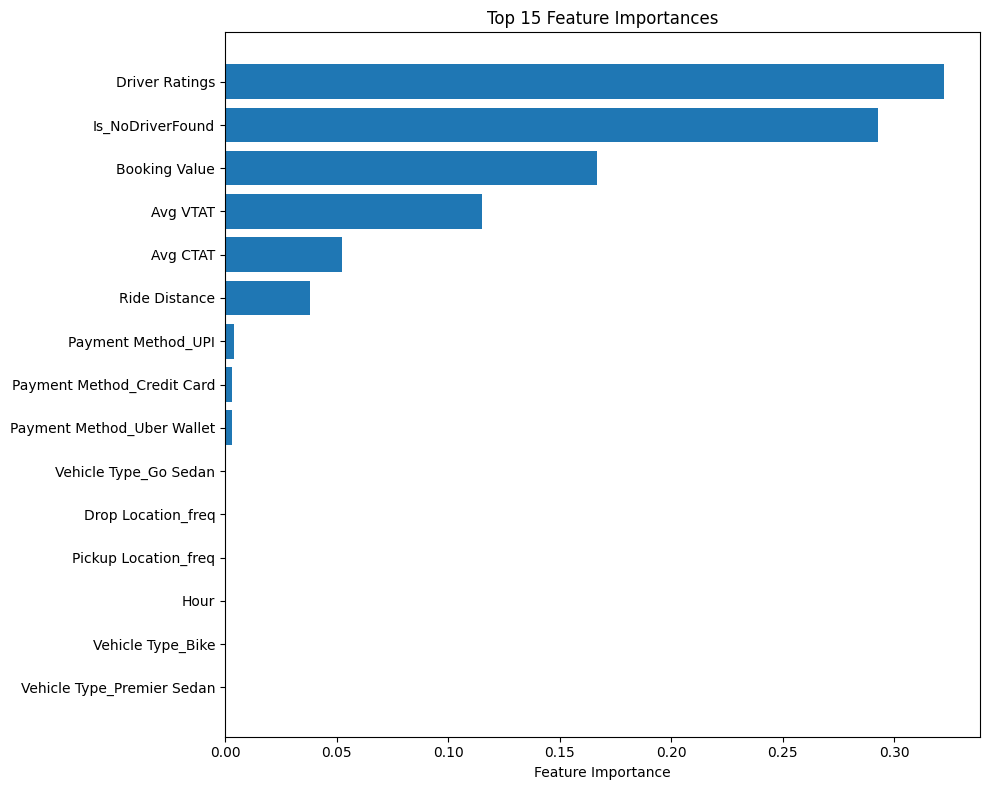

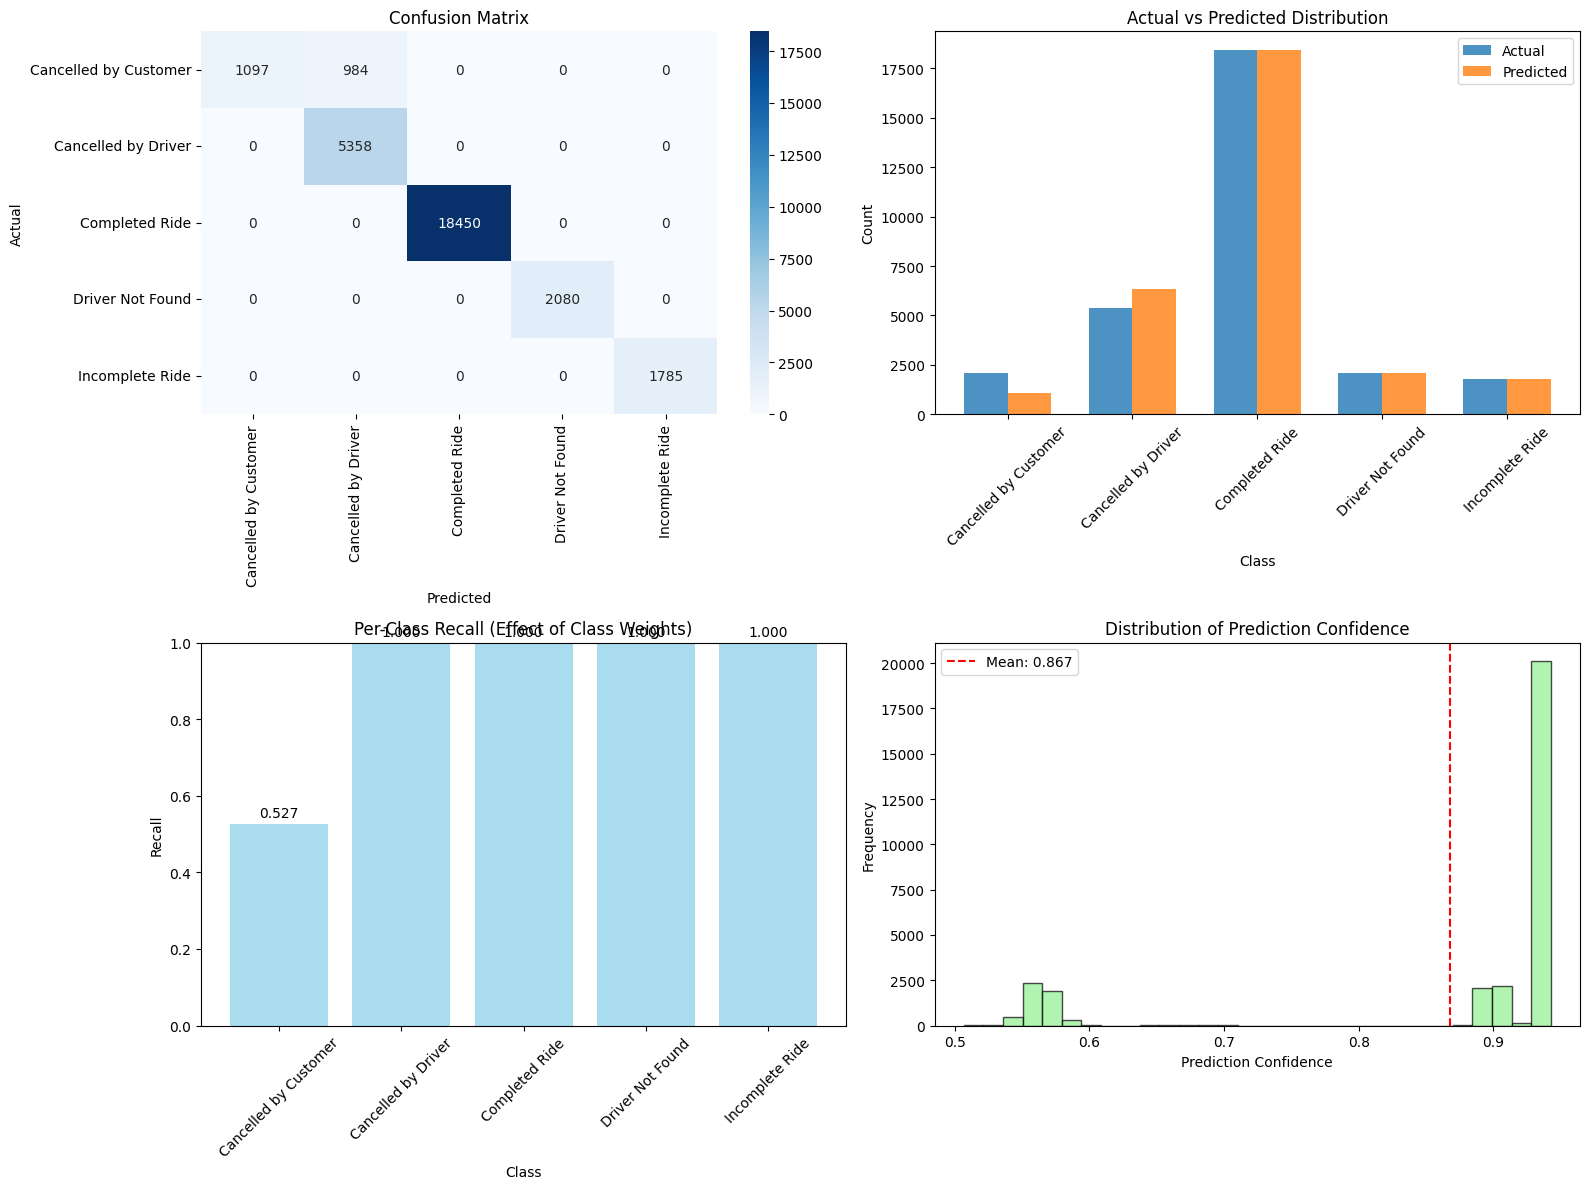

Removing target column 'Ride Status' from prediction data


In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

class WeightedXGBoostRidePredictor:
    def __init__(self, weighting_strategy='inverse_frequency', random_state=42):
        """
        XGBoost predictor using class weighting (your successful approach)
        
        Parameters:
        - weighting_strategy: 'inverse_frequency', 'balanced', or 'custom'
        - random_state: Random state for reproducibility
        """
        self.weighting_strategy = weighting_strategy
        self.random_state = random_state
        self.label_encoder = LabelEncoder()
        self.model = None
        self.class_weights = None
        self.feature_names = None
        self.target_column = None  # Store target column name
        
    def compute_class_weights(self, y_train, strategy='inverse_frequency'):
        """
        Compute class weights using different strategies
        """
        classes = np.unique(y_train)
        class_counts = np.bincount(y_train)
        
        if strategy == 'inverse_frequency':
            # Your successful approach: inverse frequency weighting
            class_weights = {cls: len(y_train) / (len(classes) * count)
                           for cls, count in zip(classes, class_counts)}
        
        elif strategy == 'balanced':
            # Sklearn's balanced approach
            class_weights = {cls: len(y_train) / (len(classes) * count)
                           for cls, count in zip(classes, class_counts)}
        
        elif strategy == 'sqrt_inverse':
            # Square root of inverse frequency (less aggressive)
            raw_weights = {cls: len(y_train) / (len(classes) * count)
                          for cls, count in zip(classes, class_counts)}
            class_weights = {cls: np.sqrt(weight) for cls, weight in raw_weights.items()}
        
        print(f"Class distribution: {dict(zip(classes, class_counts))}")
        print(f"Class weights ({strategy}): {class_weights}")
        
        return class_weights
    
    def create_xgb_model(self, num_classes, **kwargs):
        """
        Create XGBoost model with your proven configuration
        """
        default_params = {
            'objective': 'multi:softmax',  # Fixed: was binary:logistic for multiclass
            'num_class': num_classes,
            'eval_metric': 'mlogloss',  # Better for multiclass than AUC
            'random_state': self.random_state,
            'n_estimators': 300,
            'learning_rate': 0.01,
            'max_depth': 6,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.1,  # L1 regularization
            'reg_lambda': 1.0,  # L2 regularization
        }
        
        # Update with any custom parameters
        default_params.update(kwargs)
        
        return XGBClassifier(**default_params)
    
    def train(self, X, y, test_size=0.2, optimize_params=False, cv_folds=5, target_column_name=None):
        """
        Train the model using your class weighting approach
        """
        print("=== Training Class-Weighted XGBoost Model ===")
        print(f"Dataset shape: {X.shape}")
        print(f"Target distribution:\n{pd.Series(y).value_counts().sort_index()}")
        
        # Store target column name for later use in predict method
        self.target_column = target_column_name
        
        # Store feature names
        if hasattr(X, 'columns'):
            self.feature_names = X.columns.tolist()
        else:
            self.feature_names = [f'feature_{i}' for i in range(X.shape[1])]
        
        # Encode target labels
        y_encoded = self.label_encoder.fit_transform(y)
        print(f"Encoded classes: {dict(zip(self.label_encoder.classes_, range(len(self.label_encoder.classes_))))}")
        
        # Train-test split with stratification
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=test_size, stratify=y_encoded, random_state=self.random_state
        )
        
        print(f"Training set size: {X_train.shape}")
        print(f"Test set size: {X_test.shape}")
        
        # Compute class weights
        self.class_weights = self.compute_class_weights(y_train, self.weighting_strategy)
        
        # Create sample weights for training
        sample_weights = np.array([self.class_weights[cls] for cls in y_train])
        
        # Create model
        num_classes = len(np.unique(y_encoded))
        
        if optimize_params:
            print("\nOptimizing hyperparameters...")
            self.model = self.optimize_hyperparameters(X_train, y_train, sample_weights, num_classes, cv_folds)
        else:
            print("\nTraining with your proven hyperparameters...")
            self.model = self.create_xgb_model(num_classes)
        
        # Train the model with sample weights
        print("Training model with class weights...")
        self.model.fit(X_train, y_train, sample_weight=sample_weights)
        
        # Cross-validation evaluation
        if cv_folds > 1:
            print(f"\nPerforming {cv_folds}-fold cross-validation...")
            cv_scores = self.cross_validate(X_train, y_train, sample_weights, cv_folds)
        
        # Make predictions on test set
        y_pred = self.model.predict(X_test)
        y_pred_proba = self.model.predict_proba(X_test)
        
        # Store results for analysis
        self.X_test = X_test
        self.y_test = y_test
        self.y_pred = y_pred
        self.y_pred_proba = y_pred_proba
        
        # Evaluate model
        self.evaluate_model()
        
        return self.model
    
    def cross_validate(self, X_train, y_train, sample_weights, cv_folds=5):
        """
        Perform cross-validation with class weights
        """
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=self.random_state)
        cv_scores = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
            weights_fold_train = sample_weights[train_idx]
            
            # Create and train model for this fold
            fold_model = self.create_xgb_model(len(np.unique(y_train)))
            fold_model.fit(X_fold_train, y_fold_train, sample_weight=weights_fold_train)
            
            # Predict and score
            y_fold_pred = fold_model.predict(X_fold_val)
            fold_score = f1_score(y_fold_val, y_fold_pred, average='weighted')
            cv_scores.append(fold_score)
            
            print(f"Fold {fold+1} F1-Score: {fold_score:.4f}")
        
        mean_cv_score = np.mean(cv_scores)
        std_cv_score = np.std(cv_scores)
        print(f"Mean CV F1-Score: {mean_cv_score:.4f} (+/- {std_cv_score*2:.4f})")
        
        return cv_scores
    
    def optimize_hyperparameters(self, X_train, y_train, sample_weights, num_classes, cv_folds):
        """
        Optimize hyperparameters using GridSearchCV with class weights
        """
        param_grid = {
            'n_estimators': [200, 300, 400],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [4, 6, 8],
            'subsample': [0.8, 0.9],
            'colsample_bytree': [0.8, 0.9],
            'reg_alpha': [0.01, 0.1, 1.0],
            'reg_lambda': [0.1, 1.0, 10.0]
        }
        
        base_model = self.create_xgb_model(num_classes, n_estimators=100)
        
        # Custom scoring that handles sample weights
        grid_search = GridSearchCV(
            base_model,
            param_grid,
            cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=self.random_state),
            scoring='f1_weighted',
            n_jobs=-1,
            verbose=1
        )
        
        # Note: GridSearchCV doesn't directly support sample_weight
        # For full optimization, you'd need a custom implementation
        grid_search.fit(X_train, y_train)
        
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
        
        return self.create_xgb_model(num_classes, **grid_search.best_params_)
    
    def evaluate_model(self):
        """
        Comprehensive model evaluation
        """
        print("\n=== Model Performance ===")
        
        # Basic metrics
        accuracy = accuracy_score(self.y_test, self.y_pred)
        f1_weighted = f1_score(self.y_test, self.y_pred, average='weighted')
        f1_macro = f1_score(self.y_test, self.y_pred, average='macro')
        
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Weighted F1-Score: {f1_weighted:.4f}")
        print(f"Macro F1-Score: {f1_macro:.4f}")
        
        # Classification Report
        print("\nClassification Report:")
        report = classification_report(
            self.y_test, self.y_pred,
            target_names=self.label_encoder.classes_,
            digits=4
        )
        print(report)
        
        # Confusion Matrix
        print("\nConfusion Matrix:")
        cm = confusion_matrix(self.y_test, self.y_pred)
        print(cm)
        
        # Analyze class-specific performance
        self.analyze_class_balance_effectiveness()
    
    def analyze_class_balance_effectiveness(self):
        """
        Analyze how well the class weighting worked
        """
        print("\n=== Class Balance Analysis ===")
        
        cm = confusion_matrix(self.y_test, self.y_pred)
        classes = self.label_encoder.classes_
        
        print("Per-Class Metrics:")
        for i, class_name in enumerate(classes):
            tp = cm[i, i]
            total_actual = cm[i, :].sum()
            total_predicted = cm[:, i].sum()
            
            precision = tp / total_predicted if total_predicted > 0 else 0
            recall = tp / total_actual if total_actual > 0 else 0
            
            print(f"{class_name}:")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall: {recall:.4f}")
            print(f"  Support: {total_actual}")
            print(f"  Class Weight: {self.class_weights.get(i, 'N/A'):.4f}")
    
    def get_feature_importance(self, top_n=20, plot=True):
        """
        Get and visualize feature importance
        """
        if self.model is None:
            print("Model not trained yet!")
            return None
        
        importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print(f"\n=== Top {top_n} Most Important Features ===")
        print(importance_df.head(top_n))
        
        if plot:
            plt.figure(figsize=(10, 8))
            top_features = importance_df.head(top_n)
            plt.barh(range(len(top_features)), top_features['importance'])
            plt.yticks(range(len(top_features)), top_features['feature'])
            plt.xlabel('Feature Importance')
            plt.title(f'Top {top_n} Feature Importances')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
        
        return importance_df
    
    def predict(self, X_new, return_probabilities=True):
        """
        Make predictions on new data
        
        FIXED: Now properly handles the target column removal
        """
        if self.model is None:
            raise ValueError("Model not trained yet!")
        
        # Create a copy to avoid modifying the original data
        X_pred = X_new.copy()
        
        # Remove target column if it exists in the data
        if self.target_column and self.target_column in X_pred.columns:
            print(f"Removing target column '{self.target_column}' from prediction data")
            X_pred = X_pred.drop(self.target_column, axis=1)
        
        # Also check for common target column names
        target_cols_to_remove = ['Ride Status', 'target', 'label', 'y']
        for col in target_cols_to_remove:
            if col in X_pred.columns:
                print(f"Removing target-like column '{col}' from prediction data")
                X_pred = X_pred.drop(col, axis=1)
        
        # Ensure we have the same features as training
        if hasattr(X_pred, 'columns') and self.feature_names:
            missing_features = set(self.feature_names) - set(X_pred.columns)
            extra_features = set(X_pred.columns) - set(self.feature_names)
            
            if missing_features:
                print(f"Warning: Missing features in prediction data: {missing_features}")
            if extra_features:
                print(f"Warning: Extra features in prediction data (will be ignored): {extra_features}")
                X_pred = X_pred[self.feature_names]
        
        # Make predictions
        predictions_encoded = self.model.predict(X_pred)
        predictions = self.label_encoder.inverse_transform(predictions_encoded)
        
        results = pd.DataFrame({
            'Predicted_Status': predictions
        })
        
        if return_probabilities:
            probabilities = self.model.predict_proba(X_pred)
            results['Confidence'] = np.max(probabilities, axis=1)
            
            # Add probability for each class
            for i, class_name in enumerate(self.label_encoder.classes_):
                results[f'Prob_{class_name}'] = probabilities[:, i]
        
        return results
    
    def plot_results(self):
        """
        Comprehensive visualization of results
        """
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Confusion Matrix
        cm = confusion_matrix(self.y_test, self.y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
                   xticklabels=self.label_encoder.classes_,
                   yticklabels=self.label_encoder.classes_)
        axes[0,0].set_title('Confusion Matrix')
        axes[0,0].set_xlabel('Predicted')
        axes[0,0].set_ylabel('Actual')
        
        # 2. Class Distribution vs Predictions
        actual_counts = pd.Series(self.y_test).value_counts().sort_index()
        pred_counts = pd.Series(self.y_pred).value_counts().sort_index()
        
        x = np.arange(len(actual_counts))
        width = 0.35
        
        axes[0,1].bar(x - width/2, actual_counts.values, width, label='Actual', alpha=0.8)
        axes[0,1].bar(x + width/2, pred_counts.values, width, label='Predicted', alpha=0.8)
        axes[0,1].set_xlabel('Class')
        axes[0,1].set_ylabel('Count')
        axes[0,1].set_title('Actual vs Predicted Distribution')
        axes[0,1].set_xticks(x)
        axes[0,1].set_xticklabels([self.label_encoder.classes_[i] for i in actual_counts.index], rotation=45)
        axes[0,1].legend()
        
        # 3. Per-class Recall (showing effect of class weights)
        recalls = []
        for i in range(len(self.label_encoder.classes_)):
            tp = cm[i, i]
            total_actual = cm[i, :].sum()
            recall = tp / total_actual if total_actual > 0 else 0
            recalls.append(recall)
        
        axes[1,0].bar(range(len(recalls)), recalls, color='skyblue', alpha=0.7)
        axes[1,0].set_xlabel('Class')
        axes[1,0].set_ylabel('Recall')
        axes[1,0].set_title('Per-Class Recall (Effect of Class Weights)')
        axes[1,0].set_xticks(range(len(recalls)))
        axes[1,0].set_xticklabels(self.label_encoder.classes_, rotation=45)
        axes[1,0].set_ylim(0, 1)
        
        # Add recall values on bars
        for i, recall in enumerate(recalls):
            axes[1,0].text(i, recall + 0.01, f'{recall:.3f}', ha='center', va='bottom')
        
        # 4. Prediction Confidence Distribution
        confidence_scores = np.max(self.y_pred_proba, axis=1)
        axes[1,1].hist(confidence_scores, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
        axes[1,1].set_xlabel('Prediction Confidence')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title('Distribution of Prediction Confidence')
        axes[1,1].axvline(np.mean(confidence_scores), color='red', linestyle='--', 
                         label=f'Mean: {np.mean(confidence_scores):.3f}')
        axes[1,1].legend()
        
        plt.tight_layout()
        plt.show()

# UPDATED: Example usage function with target column tracking
def train_ride_status_predictor(df, target_column='Ride Status', test_size=0.2, optimize=False):
    """
    Train the ride status predictor with your data
    
    Parameters:
    - df: Your dataframe with features and target
    - target_column: Name of the target column
    - test_size: Proportion for test set
    - optimize: Whether to optimize hyperparameters
    """
    
    # Prepare data
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    
    print(f"Features: {list(X.columns)}")
    print(f"Target classes: {y.unique()}")
    
    # Initialize and train predictor
    predictor = WeightedXGBoostRidePredictor(
        weighting_strategy='inverse_frequency',  # Your successful approach
        random_state=42
    )
    
    # Train model (now passing target column name)
    model = predictor.train(
        X, y, 
        test_size=test_size, 
        optimize_params=optimize,
        cv_folds=5,
        target_column_name=target_column  # Pass the target column name
    )
    
    # Get feature importance
    predictor.get_feature_importance(top_n=15, plot=True)
    
    # Plot comprehensive results
    predictor.plot_results()
    
    return predictor

# UPDATED: Usage example with proper prediction
def make_predictions_example(df, target_column='Ride Status'):
    """
    Example of how to train and make predictions properly
    """
    # Train the model
    predictor = train_ride_status_predictor(df, target_column=target_column)
    
    # Method 1: Predict on the same data (it will automatically remove target column)
    print("Making predictions on the same dataset...")
    predictions = predictor.predict(df, return_probabilities=True)
    print(predictions.head())
    
    # Method 2: Predict on new data without target column
    print("\nMaking predictions on feature data only...")
    X_features = df.drop(target_column, axis=1)  # Remove target manually
    predictions_clean = predictor.predict(X_features, return_probabilities=True)
    print(predictions_clean.head())
    
    return predictor, predictions

# Example usage:
predictor = train_ride_status_predictor(df, target_column='Ride Status')
predictions = predictor.predict(df)  # This will now work correctly!

In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter

# -------------------------
# 1. Train/test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------
# 2. Apply SMOTE
# -------------------------
print("Before SMOTE:", Counter(y_train))
smote = SMOTE(sampling_strategy="auto", random_state=42, k_neighbors=5)
X_res, y_res = smote.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_res))

# -------------------------
# 3. Compute class weights on resampled data
# -------------------------
class_counts = Counter(y_res)
total = sum(class_counts.values())
class_weights = {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}

# Map sample weights for training set
sample_weights = np.array([class_weights[cls] for cls in y_res])

# -------------------------
# 4. Train XGBoost
# -------------------------
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    random_state=42,
    use_label_encoder=False,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist"   # faster if GPU is not available
)

xgb_model.fit(X_res, y_res, sample_weight=sample_weights)

# -------------------------
# 5. Evaluate
# -------------------------
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))


Before SMOTE: Counter({np.int64(2): 73798, np.int64(1): 21431, np.int64(0): 8321, np.int64(3): 8321, np.int64(4): 7142})
After SMOTE: Counter({np.int64(1): 73798, np.int64(2): 73798, np.int64(4): 73798, np.int64(0): 73798, np.int64(3): 73798})
              precision    recall  f1-score   support

           0      0.781     0.565     0.656      2081
           1      0.847     0.939     0.891      5358
           2      1.000     1.000     1.000     18450
           3      1.000     1.000     1.000      2080
           4      1.000     0.999     1.000      1785

    accuracy                          0.958     29754
   macro avg      0.926     0.901     0.909     29754
weighted avg      0.957     0.958     0.956     29754

